In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os
import cv2 as cv
import shutil

# print("PyTorch Version:", torch.__version__)
# print("Torchvision Version:", torchvision.__version__)
# print("GPU Available:", torch.cuda.is_available())
# print("Torchvision CUDA Build:", torchvision.__version__.split('+')[-1] if '+' in torchvision.__version__ else "Default")
# device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f'Usando dispositivo: {device}')

def dice_coef(mask_1, mask_2, title: str, graph=False):
    mask=mask_1+mask_2
    if graph:
        plt.imshow(mask)
        plt.title(title)
        plt.show()
    mask=mask.flatten()
    total_mask=len([i for i in mask if i==1])
    rate_mask=len([i for i in mask if i==2])
    return rate_mask/(total_mask+rate_mask)


def df_dice_image(H, W, annotations_revisor, annotations_persona, pixel_ref=100, interpolation=cv.INTER_LANCZOS4):
    label_labeled=[]
    label_ref=[]
    dice_coef_list=[]
    num_obj_labeled=[]
    num_obj_ref=[]
    labeled_mask=[]
    ref_mask=[]
    
    for k_ref ,obj_r in enumerate(annotations_revisor):
        nombre_clase_r = obj_r["labels"]["labelName"]
        puntos_r = np.array(
            [[p["x"], p["y"]] for p in obj_r["content"]],
            dtype=np.int32)
        
        if "frailejon" in nombre_clase_r.lower() and "sinflor" not in nombre_clase_r.lower():
            for k_lab, obj_p in enumerate(annotations_persona):
                nombre_clase_p = obj_p["labels"]["labelName"]
                
                puntos_p = np.array(
                    [[p["x"], p["y"]] for p in obj_p["content"]],
                    dtype=np.int32)
                
                try:
                    del mask_1_rev, mask_1_pers, ref_mask_resized, labeled_mask_resised
                except:
                    pass
                
                if "sinflor" not in nombre_clase_p.lower():
                    # print("no sinflorecencia")
                    label_labeled.append(nombre_clase_p)
                    label_ref.append(nombre_clase_r)
                    num_obj_labeled.append(k_lab)
                    num_obj_ref.append(k_ref)
    
                    
                    mask_1_rev = np.zeros((H, W), dtype=np.uint8)
                    cv.fillPoly(mask_1_rev, [puntos_r], color=1)
                    mask_1_pers = np.zeros((H, W), dtype=np.uint8)
                    cv.fillPoly(mask_1_pers, [puntos_p], color=1)
                    dice_coef_list.append(dice_coef(mask_1_pers, mask_1_rev, title="Pic"))
                    
                    ref_mask_resized=cv.resize(mask_1_rev, (pixel_ref, int(pixel_ref*W/H)), interpolation=interpolation)
                    ref_mask_resized=ref_mask_resized.reshape(-1)
                    ref_mask.append(ref_mask_resized)
                    labeled_mask_resised=cv.resize(mask_1_pers, (pixel_ref, int(pixel_ref*W/H)), interpolation=interpolation)
                    labeled_mask_resised=labeled_mask_resised.reshape(-1)
                    labeled_mask.append(labeled_mask_resised)
                    
                    
        
        elif "sinflor" in nombre_clase_r.lower():
            for k_lab, obj_p in enumerate(annotations_persona):
                
                nombre_clase_p = obj_p["labels"]["labelName"]
                puntos_p = np.array(
                    [[p["x"], p["y"]] for p in obj_p["content"]],
                    dtype=np.int32
                )
                try:
                    del mask_2_rev, mask_2_pers, ref_mask_resized, labeled_mask_resised
                except:
                    pass
                
    
                if "sinflor" in nombre_clase_p.lower():
                    # print("Con sinflorecencia")
                    label_labeled.append(nombre_clase_p)
                    label_ref.append(nombre_clase_r)
                    num_obj_labeled.append(k_lab)
                    num_obj_ref.append(k_ref)
                    
                    mask_2_rev = np.zeros((H, W), dtype=np.uint8)
                    cv.fillPoly(mask_2_rev, [puntos_r], color=1)
                    mask_2_pers = np.zeros((H, W), dtype=np.uint8)
                    cv.fillPoly(mask_2_pers, [puntos_p], color=1)
                    dice_coef_list.append(dice_coef(mask_2_pers, mask_2_rev, title="Cruce en etiqueta Sinflorecencia"))
                    
                    ref_mask_resized=cv.resize(mask_2_rev, (pixel_ref, int(pixel_ref*W/H)), interpolation=interpolation)
                    ref_mask_resized=ref_mask_resized.reshape(-1)
                    ref_mask.append(ref_mask_resized)
                    labeled_mask_resised=cv.resize(mask_2_pers, (pixel_ref, int(pixel_ref*W/H)), interpolation=interpolation)
                    labeled_mask_resised=labeled_mask_resised.reshape(-1)
                    labeled_mask.append(labeled_mask_resised)
                    
                    
    return label_labeled, label_ref, num_obj_labeled, num_obj_ref, dice_coef_list, labeled_mask, ref_mask

Coeficiente de Dice

$$I_{Dice}=\dfrac{2 |A\cap B|}{|A|+|B|}$$

Leer ruta

In [3]:
path_person="JuanLeal"
list_person=os.listdir(path_person)
list_images=os.listdir(os.path.join(path_person,list_person[0]))
df_general=pd.DataFrame()

for ima_name in list_images:
    ima=plt.imread(os.path.join(path_person,list_person[0],ima_name))
    # Altura y ancho de la imagen
    Height, Width = ima.shape[:2]
    df_pic=pd.DataFrame()
    #Nombre de la imagen sin extensión y sin prefijo
    pic_name=ima_name.split(".")[0].split("_")[-1]
    
    #Nombre de los json de la persona y del revisor que corresponden a la imagen
    json_referenced_name=[ i for i in os.listdir(os.path.join(path_person,list_person[2])) if pic_name in i ][0]
    json_labeled_name=[ i for i in os.listdir(os.path.join(path_person,list_person[1])) if pic_name in i ][0]
    
    #apertura de los json de la persona y del revisor que corresponden a la imagen
    with open(os.path.join(path_person,list_person[2],json_referenced_name)) as f:
        annotations_revisor = json.load(f)

    with open(os.path.join(path_person,list_person[1],json_labeled_name)) as f:
        annotations_persona = json.load(f)
    
    label_labeled, label_ref, num_obj_labeled, num_obj_ref, dice_coef_list, labeled_mask, ref_mask=df_dice_image(Height, Width, 
                                                                                                                annotations_revisor,
                                                                                                                annotations_persona,
                                                                                                                pixel_ref=256)
    
    df_pic["Name_labeler"]=[path_person]*len(label_labeled)
    df_pic["pic_name"]=[pic_name]*len(label_labeled)
    df_pic["Num_obj_ref"]=num_obj_ref
    df_pic["Num_obj_labeled"]=num_obj_labeled
    df_pic["Label_ref"]=label_ref
    df_pic["Label_labeled"]=label_labeled
    df_pic["Dice_coef"]=dice_coef_list
    df_pic["label_image_reduced"]=labeled_mask
    df_pic["ref_image_reduced"]=ref_mask
    df_pic["Dimesion_image"]=[(Height, Width)] * len(label_labeled)
    
    df_general=pd.concat([df_general, df_pic], ignore_index=True)

df_general["num_parcela"]=df_general["pic_name"].map(lambda x: x.split("C")[0])
df_general.sort_values(by=["pic_name","Num_obj_ref", "Dice_coef"], ascending=[True, True, False],inplace=True)
df_general.reset_index(drop=True, inplace=True)
df_general
    

,Name_labeler,pic_name,Num_obj_ref,Num_obj_labeled,Label_ref,Label_labeled,Dice_coef,label_image_reduced,ref_image_reduced,Dimesion_image,num_parcela
0,JuanLeal,P15C4,0,6,Frailejon,Frailejon,0.000000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
1,JuanLeal,P15C4,0,7,Frailejon,Frailejon,0.000000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
2,JuanLeal,P15C4,0,8,Frailejon,Frailejon,0.000000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
3,JuanLeal,P15C4,0,9,Frailejon,Frailejon,0.000000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
4,JuanLeal,P15C4,0,10,Frailejon,Frailejon,0.000000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
...,...,...,...,...,...,...,...,...,...,...,...
184,JuanLeal,P19C3,0,2,Frailejon,Frailejon,0.802631,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1548, 1548)",P19
185,JuanLeal,P19C3,0,3,Frailejon,Frailejon,0.000000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1548, 1548)",P19
186,JuanLeal,P19C3,0,4,Frailejon,Frailejon,0.000000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1548, 1548)",P19
187,JuanLeal,P19C3,1,1,Frailejon con sinflorecencias,Sinflorescencia,0.824423,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1548, 1548)",P19


In [4]:
df_general[(df_general["pic_name"]=="P15C4")&(df_general["Num_obj_ref"]==2)]

,Name_labeler,pic_name,Num_obj_ref,Num_obj_labeled,Label_ref,Label_labeled,Dice_coef,label_image_reduced,ref_image_reduced,Dimesion_image,num_parcela
62,JuanLeal,P15C4,2,6,Frailejon,Frailejon,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
63,JuanLeal,P15C4,2,7,Frailejon,Frailejon,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
64,JuanLeal,P15C4,2,8,Frailejon,Frailejon,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
65,JuanLeal,P15C4,2,9,Frailejon,Frailejon,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
66,JuanLeal,P15C4,2,10,Frailejon,Frailejon,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
67,JuanLeal,P15C4,2,11,Frailejon,Frailejon,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
68,JuanLeal,P15C4,2,13,Frailejon,Frailejon,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
69,JuanLeal,P15C4,2,14,Frailejon,Frailejon,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
70,JuanLeal,P15C4,2,15,Frailejon,Frailejon,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15
71,JuanLeal,P15C4,2,16,Frailejon,Frailejon,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(1613, 1757)",P15


In [90]:
df_general.to_csv("df_general.csv", index=False, sep=";")

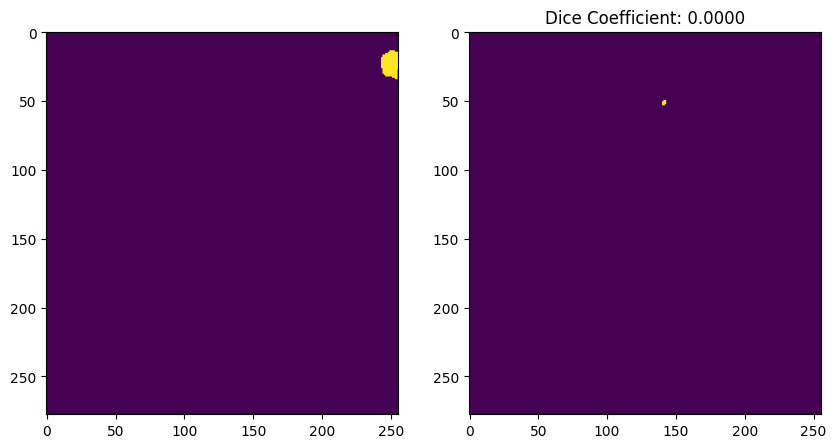

In [5]:
n=92
label_ima=df_general.iloc[n]["label_image_reduced"].reshape(len(df_general.iloc[n]["label_image_reduced"])//256, 256)
ref_ima=df_general.iloc[n]["ref_image_reduced"].reshape(len(df_general.iloc[n]["ref_image_reduced"])//256, 256)

fig, ax= plt.subplots(1, 2, figsize=(10, 5)) 
ax[0].imshow(label_ima)
ax[1].imshow(ref_ima)
plt.title(f"Dice Coefficient: {df_general.iloc[n]['Dice_coef']:.4f}")
plt.show()

In [32]:
lista_personas="diego.torres53408@ucaldas.edu.co, mosquitolima88@gmail.com, cacicuscela27@gmail.com, amclavijog@unal.edu.co, zuluaga.alejandro@correounivalle.edu.co, sara.castro3709@gmail.com, gcardenasposada@gmail.com, maleryw2@gmail.com, ruapardoma@gmail.com, elkalexno@gmail.com, ycsaavedrasaenz@gmail.com, mauriciomatomacardona@gmail.com, juvvinascom@upn.edu.co, alexmauriciolopez1995@gmail.com, lvclavijor@unal.edu.co, paunavarrosalcedo@gmail.com, cemedinag@unal.edu.co, karoldanielaaguilarrios@hotmail.com, jherandyne@gmail.com, nchavez@javeriana.edu.co, fausto.saenz@uptc.edu.co, dlombanab@unal.edu.co, nabenavidesl@ut.edu.co, mila.chapas12@gmail.com, hagranadade@ut.edu.co, pasarmientog@unal.edu.co, lmhernandezhe@unal.edu.co, ndcamargom@unal.edu.co, stefania.dime20@gmail.com, gasilvaa@unal.edu.co, vrincon25@unisalle.edu.co, cardona.londono.juliana@gmail.com, leidy.gil04@uptc.edu.co, bfrancog@unal.edu.co, valeria.rangel@javeriana.edu.co, fagomezj@unal.edu.co, dmartinez@humboldt.org.co, nbetancourtc@humboldt.org.co, juanita.rodriguez.serrano@gmail.com, atorresgalvis@gmail.com".split(",")
lista_personas=[i.strip() for i in lista_personas]
lista_personas=[i.split("@")[0] for i in lista_personas]
lista_personas=[i.replace(".","") for i in lista_personas]

images_path="RECORTES CON NOMBRE"
ref_path="Referencias recortes"
ref_list=os.listdir(ref_path)
image_list=os.listdir(images_path)


file_person_path="Personas"
for k, person in enumerate(lista_personas):
    os.makedirs(os.path.join(file_person_path, person),exist_ok=True)
    os.makedirs(os.path.join(file_person_path, person, "Images"),exist_ok=True)
    os.makedirs(os.path.join(file_person_path, person, "Labeled"),exist_ok=True)
    os.makedirs(os.path.join(file_person_path, person, "References"),exist_ok=True)
    origen_images=[os.path.join(images_path, img) for img in image_list[3*k:3*(k+1)]]
    origen_references=[os.path.join(ref_path, ref.split(".")[0]+".json") for ref in image_list[3*k:3*(k+1)]]
    
    destino_images=[os.path.join(file_person_path, person, "Images", person+"_"+img) for img in image_list[3*k:3*(k+1)]]
    destino_references=[os.path.join(file_person_path, person, "References", ref.split(".")[0]+".json") for ref in image_list[3*k:3*(k+1)]]
    
    for i in range(3):
        try:
            shutil.move(origen_images[i], destino_images[i])
            shutil.move(origen_references[i], destino_references[i])
        except:
            file=origen_references[i].split('\\')[-1]
            print(f"Error occurred while moving files for person {person}: {file}")

# Ruta de origen (archivo actual) y ruta de destino (nueva ubicación)
# origen = "mi_archivo.txt"
# destino = "carpeta_destino/mi_archivo.txt"

# # Mover el archivo (equivalente a cortar y pegar)
# shutil.move(origen, destino)
# print("Archivo movido con éxito.")

In [28]:
origen_references[i].split("\\")[-1]

'P51C2.json'

In [33]:
person

'atorresgalvis'